In [9]:
import pandas as pd

from crypto.factor import mom_factor, rev_factor

close=pd.read_csv('D:/python-practise/data-analyse/crypto/close_clean.csv',index_col=0, parse_dates=True)
vol_factor=pd.read_csv('D:/python-practise/data-analyse/crypto/vol_factor.csv',index_col=0, parse_dates=True)
returns = close.pct_change()
vol_factor=vol_factor.loc['2020-11-22':]
returns=returns.loc['2020-11-22':]

C:\Users\Thinkpad\AppData\Local\Temp\ipykernel_3632\1943884736.py:7: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = close.pct_change()


In [10]:
def layer_backtest(factor,returns,n_layers=5):
     """Daily equal-weighted returns for factor-sorted quantiles (groups)"""
     layer_returns={f'Q{i+1}':[] for i in range(n_layers)}
     dates=[]
     for date in factor.index:
         f=factor.loc[date].dropna()
         if len(f)<n_layers*2:
             continue
         r=returns.loc[date]
         try:
             lables=pd.qcut(f,n_layers,labels=False,duplicates='drop')
         except ValueError:
             continue
         dates.append(date)
         for i in range(n_layers):
             members=f.index[lables==i]
             # Quantile equal-weighted return = mean of daily returns for tokens in this tier
             layer_ret=r[members].mean()
             layer_returns[f'Q{i+1}'].append(layer_ret)
     return pd.DataFrame(layer_returns,index=dates)
layer_ret=layer_backtest(vol_factor,returns)
print(layer_ret.head())
print("Mean Daily Return by Quantile：")
print(layer_ret.mean())
print(layer_ret.median())

                                 Q1        Q2        Q3        Q4        Q5
2020-11-22 00:00:00+00:00 -0.013796 -0.055048 -0.003603 -0.042871 -0.052281
2020-11-23 00:00:00+00:00  0.041736  0.075486  0.110896  0.241242  0.092000
2020-11-24 00:00:00+00:00  0.043200  0.035365  0.053979  0.180563  0.037528
2020-11-25 00:00:00+00:00 -0.051642 -0.077055 -0.086476 -0.101915 -0.060581
2020-11-26 00:00:00+00:00 -0.084329 -0.105026 -0.123198 -0.085152 -0.078616
Mean Daily Return by Quantile：
Q1    0.001407
Q2    0.001764
Q3    0.001195
Q4    0.002112
Q5    0.002468
dtype: float64
Q1    0.001540
Q2    0.001881
Q3    0.002038
Q4    0.001400
Q5    0.001212
dtype: float64


In [11]:
d = '2023-06-01'
raw_vol = returns.rolling(20).std()
top_factor_coin = vol_factor.loc[d].idxmax()
print(f"{d} Coin has the largest volatility: {top_factor_coin}")
print(f"Raw Volatility: {raw_vol.loc[d, top_factor_coin]:.4f}")
print(f"Daily range of raw volatilities across all tokens: {raw_vol.loc[d].min():.4f} ~ {raw_vol.loc[d].max():.4f}")

2023-06-01 Coin has the largest volatility: PEPE/USDT
Raw Volatility: 0.0557
Daily range of raw volatilities across all tokens: 0.0097 ~ 0.0557


In [12]:
from scipy.stats import spearmanr
def quick_ic(factor, ret):
    ics = []
    for date in factor.index:
        f, r = factor.loc[date], ret.loc[date]
        mask = f.notna() & r.notna()
        if mask.sum() > 5:
            ics.append(spearmanr(f[mask], r[mask]).correlation)
    return pd.Series(ics).mean()
print("The current IC of vol_factor:", quick_ic(vol_factor, returns))

The current IC of vol_factor: -0.07142662065944169


In [13]:
mom_factor=pd.read_csv('D:/python-practise/data-analyse/crypto/mom_factor.csv',index_col=0, parse_dates=True)
rev_factor=pd.read_csv('D:/python-practise/data-analyse/crypto/rev_factor.csv',index_col=0, parse_dates=True)
mom_factor=mom_factor.loc['2020-11-22':]
rev_factor=rev_factor.loc['2020-11-22':]
for name, factor in [('momentum',mom_factor),('reversal',rev_factor)]:
    df=layer_backtest(factor, returns)
    print(f"\n====={name}factor=====")
    print('Mean Return by Quantile：',df.mean())
    print('Median Return by Quantile：',df.median())
    print("Current IC：",quick_ic(factor, returns))


=====momentumfactor=====
Mean Return by Quantile： Q1    0.001287
Q2    0.000590
Q3    0.001528
Q4    0.002371
Q5    0.003246
dtype: float64
Median Return by Quantile： Q1    0.000827
Q2    0.000698
Q3    0.001671
Q4    0.001753
Q5    0.001876
dtype: float64
Current IC： -0.01212564044598195

=====reversalfactor=====
Mean Return by Quantile： Q1    0.003492
Q2    0.001747
Q3    0.001407
Q4    0.001045
Q5    0.001249
dtype: float64
Median Return by Quantile： Q1    0.001199
Q2    0.002155
Q3    0.001248
Q4    0.001107
Q5    0.001222
dtype: float64
Current IC： 0.02339323609895854


In [15]:
import matplotlib.pyplot as plt
def build_weights(factor, n_layers=5):
    """Daily equal-weighted dollar-neutral portfolio: +1/N in Q1 (low-vol) and -1/N in Q5 (high-vol)."""
    weights=pd.DataFrame(0.0,index=factor.index,columns=factor.columns)
    for date in factor.index:
        f=factor.loc[date].dropna()
        if len(f)<n_layers*2:
            continue
        lables=pd.qcut(f,n_layers,labels=False,duplicates='drop')
        q1=f.index[lables==0]
        q5=f.index[lables==n_layers-1]
        weights.loc[date,q1]=1/len(q1)
        weights.loc[date,q5]=-1/len(q5)
    return weights
weights=build_weights(vol_factor)
port_ret=(weights*returns).sum(axis=1)
port_ret=port_ret.loc[weights.abs().sum(axis=1) > 0]
nav_gross=(1+port_ret).cumprod()
print("Frictionless Final NAV ：",round(nav_gross.iloc[-1],3))

Frictionless Final NAV ： 0.026


In [16]:
turnover=weights.diff().abs().sum(axis=1)
COST_RATE=0.001
cost=turnover*COST_RATE
net_ret=(weights*returns).sum(axis=1)-cost
net_ret=net_ret.loc[weights.abs().sum(axis=1) > 0]
nav_net=(1+net_ret).cumprod()
print("After-Cost Final Net Value:", round(nav_net.iloc[-1], 3))
print("Mean Daily Turnover:", round(turnover.mean(), 3))

After-Cost Final Net Value: 0.013
Mean Daily Turnover: 0.328


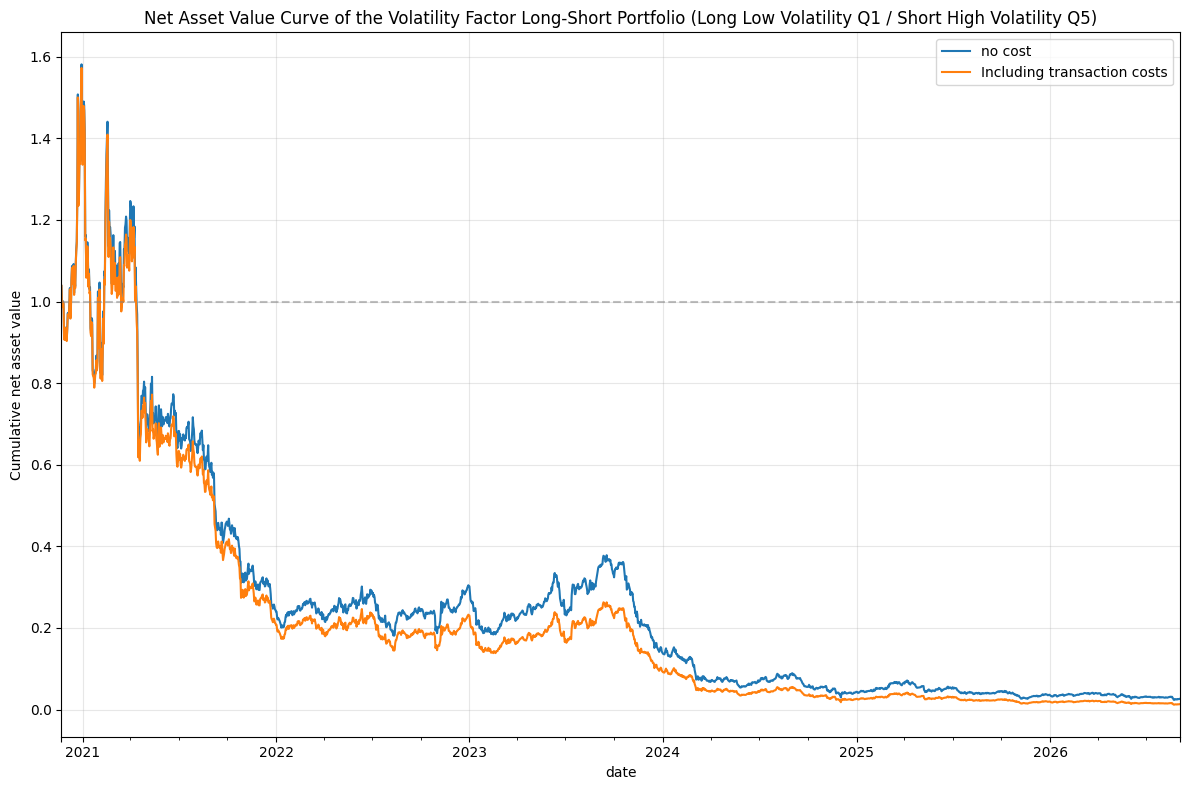

<Figure size 640x480 with 0 Axes>

In [17]:
plt.figure(figsize=(12,8))
nav_gross.plot(label="no cost")
nav_net.plot(label="Including transaction costs")
plt.title('Net Asset Value Curve of the Volatility Factor Long-Short Portfolio (Long Low Volatility Q1 / Short High Volatility Q5)')
plt.xlabel('date'); plt.ylabel('Cumulative net asset value')
plt.legend(); plt.grid(alpha=0.3)
plt.axhline(1, color='gray', ls='--', alpha=0.5)   # 1 是本金线
plt.tight_layout()
plt.show()
plt.savefig('net_value_(cost vs no cost).png', dpi=150, bbox_inches='tight')

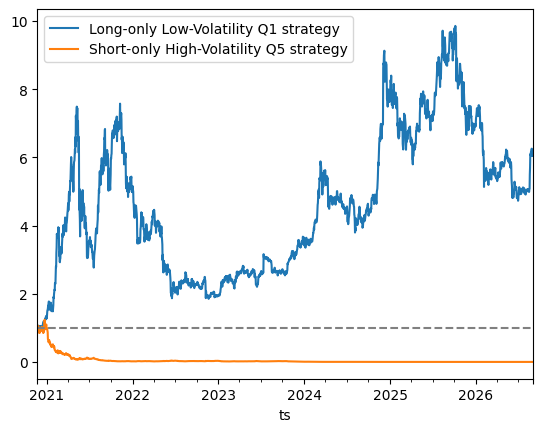

Long leg: 6.055  Short leg: 0.0


<Figure size 640x480 with 0 Axes>

In [19]:
w_long = build_weights(vol_factor).clip(lower=0)
long_ret = (w_long * returns).sum(axis=1)
nav_long = (1 + long_ret[long_ret!=0]).cumprod()

w_short = build_weights(vol_factor).clip(upper=0)
short_ret = (w_short * returns).sum(axis=1)
nav_short = (1 + short_ret[short_ret!=0]).cumprod()

nav_long.plot(label='Long-only Low-Volatility Q1 strategy')
nav_short.plot(label='Short-only High-Volatility Q5 strategy')
plt.legend(); plt.axhline(1, ls='--', color='gray'); plt.show()
plt.savefig('long Q1 vs short Q5.png', dpi=150, bbox_inches='tight')
print("Long leg:", round(nav_long.iloc[-1],3), " Short leg:", round(nav_short.iloc[-1],3))

In [20]:
w_long = build_weights(vol_factor).clip(lower=0)
long_ret = (w_long * returns).sum(axis=1)
long_ret = long_ret[w_long.abs().sum(axis=1) > 0]
benchmark_ret = returns.loc[long_ret.index].mean(axis=1)

In [21]:
import numpy as np
def performance_stats(daily_ret, name, periods=365):
    daily_ret = daily_ret.dropna()
    nav = (1 + daily_ret).cumprod()
    total = nav.iloc[-1] - 1
    ann_ret = (1 + daily_ret.mean()) ** periods - 1
    ann_vol = daily_ret.std() * np.sqrt(periods)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else np.nan
    # mdd
    peak = nav.cummax()
    drawdown = (nav - peak) / peak
    mdd = drawdown.min()
    print(f"===== {name} =====")
    print(f"total return: {total:.1%}  Annualized return: {ann_ret:.1%}  Annualized volatility: {ann_vol:.1%}")
    print(f"sharpe: {sharpe:.2f}  mdd: {mdd:.1%}")
    return {'sharpe': sharpe, 'mdd': mdd, 'ann_ret': ann_ret}

s_long = performance_stats(long_ret, "Long Leg (Low-Volatility Q1)")
s_bench = performance_stats(benchmark_ret, "Benchmark (Equal-Weighted Full Universe)")

===== Long Leg (Low-Volatility Q1) =====
total return: 505.5%  Annualized return: 67.1%  Annualized volatility: 63.3%
sharpe: 1.06  mdd: -75.6%
===== Benchmark (Equal-Weighted Full Universe) =====
total return: 710.7%  Annualized return: 92.9%  Annualized volatility: 76.4%
sharpe: 1.22  mdd: -79.9%


===== Excess Return (Long Leg - Market) =====
total return: -68.6%  Annualized return: -13.4%  Annualized volatility: 33.2%
sharpe: -0.40  mdd: -79.7%


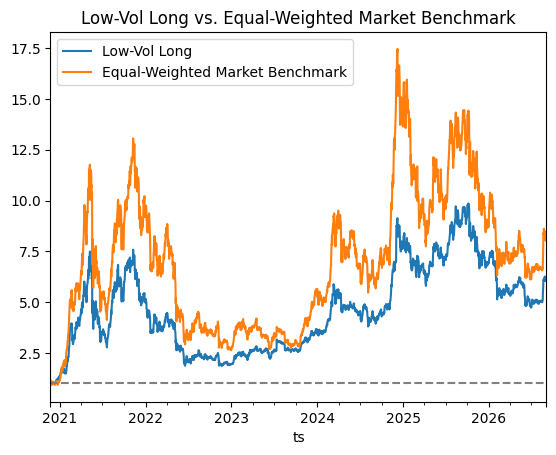

<Figure size 640x480 with 0 Axes>

In [22]:
# 超额收益 = 多头腿 - 基准
excess_ret = long_ret - benchmark_ret
performance_stats(excess_ret, "Excess Return (Long Leg - Market)")

# 多空对比净值图
(1+long_ret).cumprod().plot(label='Low-Vol Long')
(1+benchmark_ret).cumprod().plot(label='Equal-Weighted Market Benchmark')
plt.legend(); plt.axhline(1, ls='--', color='gray')
plt.title('Low-Vol Long vs. Equal-Weighted Market Benchmark'); plt.show()
plt.savefig('Low-Vol Long vs. Equal-Weighted Market Benchmark.png', dpi=150, bbox_inches='tight')

In [23]:
split = int(len(long_ret) * 0.7)
performance_stats(long_ret.iloc[:split], "Top 70% quantile of the In-Sample long leg")
performance_stats(long_ret.iloc[split:], "Top 30% quantile of the Out-Sample long leg")

===== Top 70% quantile of the In-Sample long leg =====
total return: 813.0%  Annualized return: 119.7%  Annualized volatility: 69.2%
sharpe: 1.73  mdd: -75.6%
===== Top 30% quantile of the Out-Sample long leg =====
total return: -33.7%  Annualized return: -11.9%  Annualized volatility: 46.7%
sharpe: -0.25  mdd: -52.0%


{'sharpe': np.float64(-0.2542550643581123),
 'mdd': np.float64(-0.5202870453178766),
 'ann_ret': np.float64(-0.11871733280792407)}

In [24]:
volume=pd.read_csv('D:/python-practise/data-analyse/crypto/volume_clean.csv',index_col=0, parse_dates=True)
size=np.log(volume*close).replace([np.inf,-np.inf],np.nan).shift(1)
print("number of inf",np.isinf(size).sum().sum())
print(size.iloc[100:103,:4])

number of inf 0
                            BTC/USDT   ETH/USDT   BNB/USDT   XRP/USDT
ts                                                                   
2020-04-10 00:00:00+00:00  19.913556  18.619751  18.058574  16.845919
2020-04-11 00:00:00+00:00  20.391917  19.150618  17.820629  17.221825
2020-04-12 00:00:00+00:00  19.560728  18.404733  17.747076  16.757988


In [25]:
from statsmodels.api import OLS, add_constant
def neutralize(factor,size):
    result=pd.DataFrame(index=factor.index,columns=factor.columns)
    for date in factor.index:
        y=factor.loc[date]
        x=size.loc[date]
        df=pd.concat([y,x],axis=1).dropna()
        if len(df)<5:
            continue
        y_clean=df.iloc[:,0]
        x_clean=df.iloc[:,1]
        model=OLS(y_clean,add_constant(x_clean)).fit()
        resid=model.resid
        result.loc[date,resid.index]=resid
    return result

In [26]:
vol_neutral=neutralize(vol_factor,size)
print("shape",vol_neutral.shape)
print("Number of non-null values：",vol_neutral.notna().sum().sum())
print(vol_neutral.iloc[100:103,:4])

shape (2112, 31)
Number of non-null values： 44822
                           BTC/USDT  ETH/USDT  BNB/USDT  XRP/USDT
ts                                                               
2021-03-02 00:00:00+00:00 -0.896042 -0.943989  2.895875 -0.479611
2021-03-03 00:00:00+00:00 -0.909571 -0.898309  3.593463 -0.393176
2021-03-04 00:00:00+00:00 -0.963386 -0.841349  3.552667 -0.332799


In [27]:
print("Raw：",quick_ic(vol_factor,returns))
print("Post-neutralized：",quick_ic(vol_neutral,returns))

Raw： -0.07142662065944169
Post-neutralized： -0.06536467760650377
